# **MiniBooNE**

**Note:** This is a pretty rough first look, but can help decide which is easiest to work w/

**Link:** https://archive.ics.uci.edu/dataset/199/miniboone+particle+identification

This one is nice because it is the only physics dataset that has true null values/sensor malfunctions to address. The primary downside is that it is featureless, though for the context of a ML application, that may be fine as long as the model is accurate and precise. I believe this would be a good candidate for XGBoost.

Compared to the air brake dataset, this one is not multivariable, only two categories (muon/neutrino) encoded as 1 or 0, which works well with RF too, automatically takes as a boolean

---

In [38]:
# Global imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

In [39]:
# This is the only thing that really needs to change when looking from dataset to dataset, run everything else that follows as normal

DATA_PATH = "MiniBooNE_PID.txt"
SKIPROWS = 1          # line 1 holds signal/background counts, not data
NA_VALUES = -999.0    # MiniBooNE's sentinel value for bad/missing readings
TARGET_COL = "class"  # constructed below - not present in the raw file
TOP_K = 30

In [40]:
# Load the data

with open(DATA_PATH) as f:
    n_signal, n_background = (int(x) for x in f.readline().split())
 
col_names = [f"f{i}" for i in range(50)]
 
df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=col_names,
    skiprows=SKIPROWS,
    na_values=NA_VALUES
)

df[TARGET_COL] = ["signal"] * n_signal + ["background"] * n_background

print(f"Shape: {df.shape}")
df.head(10)

Task was destroyed but it is pending!
task: <Task pending name='Task-212' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/zendevs/study/venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-213' coro=<Kernel.shell_main() running at /home/zendevs/study/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/zendevs/study/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/zendevs/study/venv/lib/python3.12/site-packages/pandas/core/internals/blocks.py:650: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return type(self)(values, placement=self._mgr_locs, ndim=self.ndim, refs=refs)
Task was destroyed but it is pending!
task: <Task pending name='Task-213' coro=<Kernel.shell_main() running at /home/zendevs/study/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Shape: (130064, 51)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,...,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,class
0,2.59413,0.468803,20.69160,0.322648,0.009682,0.374393,0.803479,0.896592,3.59665,0.249282,4.18624,135.8850,0.928671,0.140918,2.58663,1689.070,1.197950,19.3561,0.398340,0.658684,1.561270,0.320885,108.8560,5.16994,0.491493,...,29.61410,1.22299,0.190005,-0.654163,4.97666,0.908007,0.385076,377.412,0.136108,0.310650,2.952640,-4.55567,0.934167,0.049752,101.174,-31.3730,0.442259,5.86453,0.000000,0.090519,0.176909,0.457585,0.071769,0.245996,signal
1,3.86388,0.645781,18.13750,0.233529,0.030733,0.361239,1.069740,0.878714,3.59243,0.200793,4.65578,331.7180,0.882784,0.368855,2.24638,1388.260,0.839230,6.6951,0.277778,0.944626,1.664640,0.256501,102.4930,5.33218,0.474294,...,31.57670,1.31717,0.141945,0.093886,5.05478,1.394390,0.325034,215.837,0.082048,0.297530,0.777241,-4.76871,1.438210,0.068714,186.516,45.9597,-0.478507,6.11126,0.001182,0.091800,-0.465572,0.935523,0.333613,0.230621,signal
2,3.38584,1.197140,36.08070,0.200866,0.017341,0.260841,1.108950,0.884405,3.43159,0.177167,4.50807,159.3960,0.412250,0.434002,2.38485,992.098,0.514175,16.0030,0.256262,0.318984,-0.727361,0.312139,69.8362,3.44976,0.497076,...,59.25160,1.18765,0.192565,-0.511144,5.27196,1.002860,1.690870,417.430,0.068628,0.220612,1.390970,-2.02213,1.843790,0.085132,129.931,-11.5608,-0.297008,8.27204,0.003854,0.141721,-0.210559,1.013450,0.255512,0.180901,signal
3,4.28524,0.510155,674.20100,0.281923,0.009174,0.000000,0.998822,0.823390,3.16382,0.171678,4.08041,-1.8656,0.833067,0.181294,2.49837,1289.160,0.630307,12.9374,0.266055,1.313580,0.698101,0.306193,148.0340,4.12461,0.494778,...,17.82650,1.70034,0.147487,0.313964,7.91668,1.584410,0.557134,352.699,0.079246,0.338915,-0.331218,-3.52184,1.244390,0.105550,163.978,-18.4586,0.453886,2.48112,0.000000,0.180938,0.407968,4.341270,0.473081,0.258990,signal
4,5.93662,0.832993,59.87960,0.232853,0.025066,0.233556,1.370040,0.787424,3.66546,0.174862,4.59180,183.6680,0.398421,0.353034,2.04136,949.231,0.389585,13.9175,0.281003,0.282402,-0.039672,0.233509,106.8670,2.94245,0.464260,...,139.47000,1.68793,0.117804,0.021927,7.80990,1.317420,0.677348,317.556,0.041526,0.249403,-0.360560,-3.18766,1.808670,0.105852,229.555,42.9600,-0.975752,2.66109,0.000000,0.170836,-0.814403,4.679490,1.924990,0.253893,signal
5,4.41251,2.157210,66.78530,0.335389,0.004274,0.133690,0.696868,0.753386,3.45575,0.150908,4.43856,283.4460,-0.463347,0.130846,1.55108,507.203,0.217193,26.7389,0.279915,1.711220,1.849230,0.322650,47.5931,3.94517,0.318723,...,1.92807,1.62665,0.173143,0.107052,8.01805,1.106800,1.382390,247.024,0.064414,0.366645,-0.253309,-2.77602,1.186040,0.107764,153.943,-18.5469,0.638310,5.97304,0.000000,0.156063,0.458479,3.500280,3.616290,0.189857,signal
6,3.41292,0.834852,45.59630,0.253942,0.009479,0.290691,1.273870,0.891223,3.42853,0.227561,4.44664,206.0020,0.836173,0.165293,2.50378,1236.870,0.764262,10.1579,0.312796,1.204170,0.734373,0.278041,78.5687,5.25039,0.460170,...,36.71200,1.28721,0.178021,-0.155264,4.46572,1.094450,0.888741,350.018,0.107955,0.304557,0.599385,-3.36935,1.274070,0.057235,137.419,-11.3654,0.060045,4.85395,0.000000,0.102631,-0.036952,0.862529,0.671407,0.254095,signal
7,2.93345,0.243213,9.73308,0.243312,0.018536,0.516637,1.188590,0.904027,3.38835,0.240489,4.21186,347.5260,0.965842,0.233656,3.41256,3108.840,2.310740,17.2510,0.352178,0.687643,0.729926,0.301205,269.1070,5.14453,0.483675,...,32.61880,1.05909,0.169283,-0.131039,5.25768,1.282810,0.516373,216.726,0.135178,0.360110,2.710240,-4.43169,1.460420,0.065757,148.262,-25.0214,0.015407,4.66803,0.001854,0.108072,-0.149434,0.451253,-0.182719,0.229547,signal
8,4.10757,0.682600,83.69250,0.263911,0.005181,0.168942,1.403150,0.889605,3.26032,0.187648,4.16345,145.9490,0.403241,0.146151,2.64477,1428.180,0.777926,14.7445,0.288860,0.969137,0.632569,0.345855,134.1100,3.53646,0.493146,...,48.32080,1.56085,0.162458

In [41]:
# Basic info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130064 entries, 0 to 130063
Data columns (total 51 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   f0      129596 non-null  float64
 1   f1      129596 non-null  float64
 2   f2      129596 non-null  float64
 3   f3      129596 non-null  float64
 4   f4      129596 non-null  float64
 5   f5      129596 non-null  float64
 6   f6      129596 non-null  float64
 7   f7      129596 non-null  float64
 8   f8      129596 non-null  float64
 9   f9      129596 non-null  float64
 10  f10     129596 non-null  float64
 11  f11     129596 non-null  float64
 12  f12     129596 non-null  float64
 13  f13     129596 non-null  float64
 14  f14     129596 non-null  float64
 15  f15     129596 non-null  float64
 16  f16     129596 non-null  float64
 17  f17     129596 non-null  float64
 18  f18     129596 non-null  float64
 19  f19     129596 non-null  float64
 20  f20     129596 non-null  float64
 21  f21     129596 non-nu

In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,129596.0,4.863931,1.161277,0.000000,4.021948,4.793385,5.632045,1.705730e+01
f1,129596.0,1.492450,0.860538,0.059691,0.882372,1.385640,1.950260,8.802820e+00
f2,129596.0,127.849703,184.363509,0.012381,49.978850,106.423000,138.994000,4.747670e+03
f3,129596.0,0.283131,0.059554,0.104697,0.241901,0.272313,0.315312,7.368040e-01
f4,129596.0,0.009311,0.012493,-0.156118,0.001245,0.005013,0.013183,1.790120e-01
f5,129596.0,0.160797,0.122911,0.000000,0.086348,0.141468,0.213450,7.038590e-01
f6,129596.0,0.970221,0.342953,0.000000,0.717548,0.924167,1.181227,6.241080e+00
f7,129596.0,0.823904,0.070467,0.033510,0.783985,0.834243,0.874354,9.897130e-01
f8,129596.0,3.451369,0.258654,2.375270,3.286500,3.427935,3.586220,7.170170e+00
f9,129596.0,0.173899,0.043707,0.033432,0.143172,0.170756,0.200121,5.248880e-01


In [43]:
if TARGET_COL in df.columns:
    print(df[TARGET_COL].value_counts())
    print()
    print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
else:
    print(f"Column '{TARGET_COL}' not found — update TARGET_COL in the config cell.")

class
background    93565
signal        36499
Name: count, dtype: int64

class
background    71.94 %
signal        28.06 %
Name: proportion, dtype: str


In [44]:
# Null value check

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
 
null_summary = (
    pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
 
print(f"Columns with at least one missing value: {len(null_summary)} / {df.shape[1]}")
null_summary.head(30)

# shows 0, even though it is -999.0

Columns with at least one missing value: 50 / 51


,n_missing,pct_missing
f0,468,0.36
f1,468,0.36
f2,468,0.36
f3,468,0.36
f4,468,0.36
f5,468,0.36
f6,468,0.36
f7,468,0.36
f8,468,0.36
f9,468,0.36


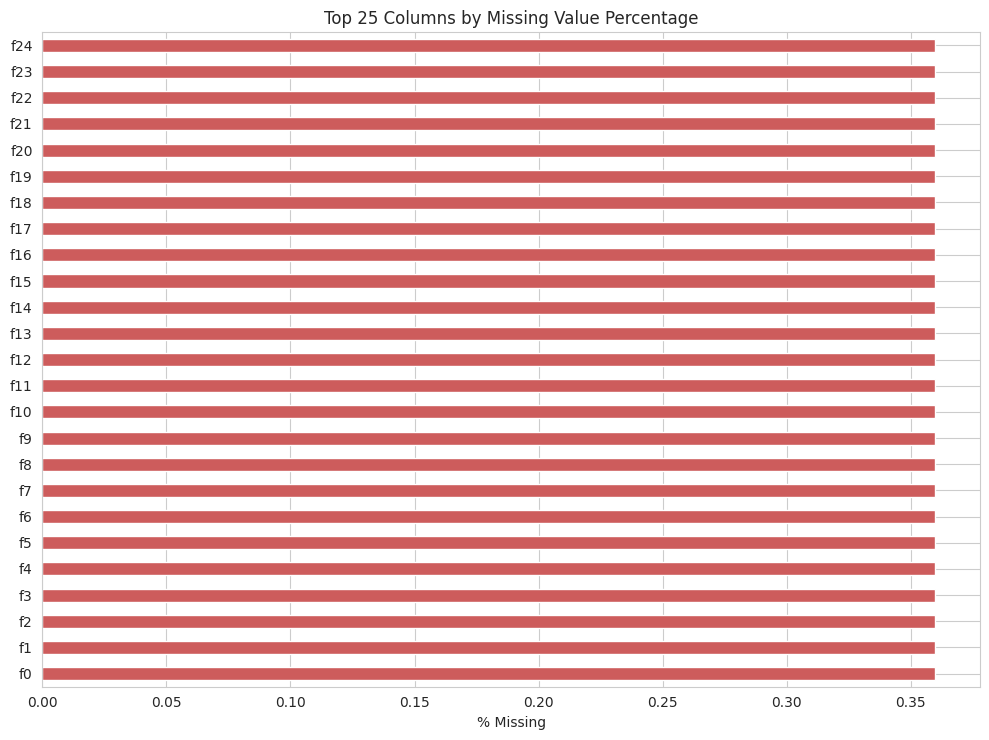

In [45]:
top_n_missing = min(25, len(null_summary))
 
if top_n_missing > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, top_n_missing * 0.3)))
    null_summary.head(top_n_missing)["pct_missing"].sort_values().plot(
        kind="barh", ax=ax, color="indianred"
    )
    ax.set_xlabel("% Missing")
    ax.set_title(f"Top {top_n_missing} Columns by Missing Value Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

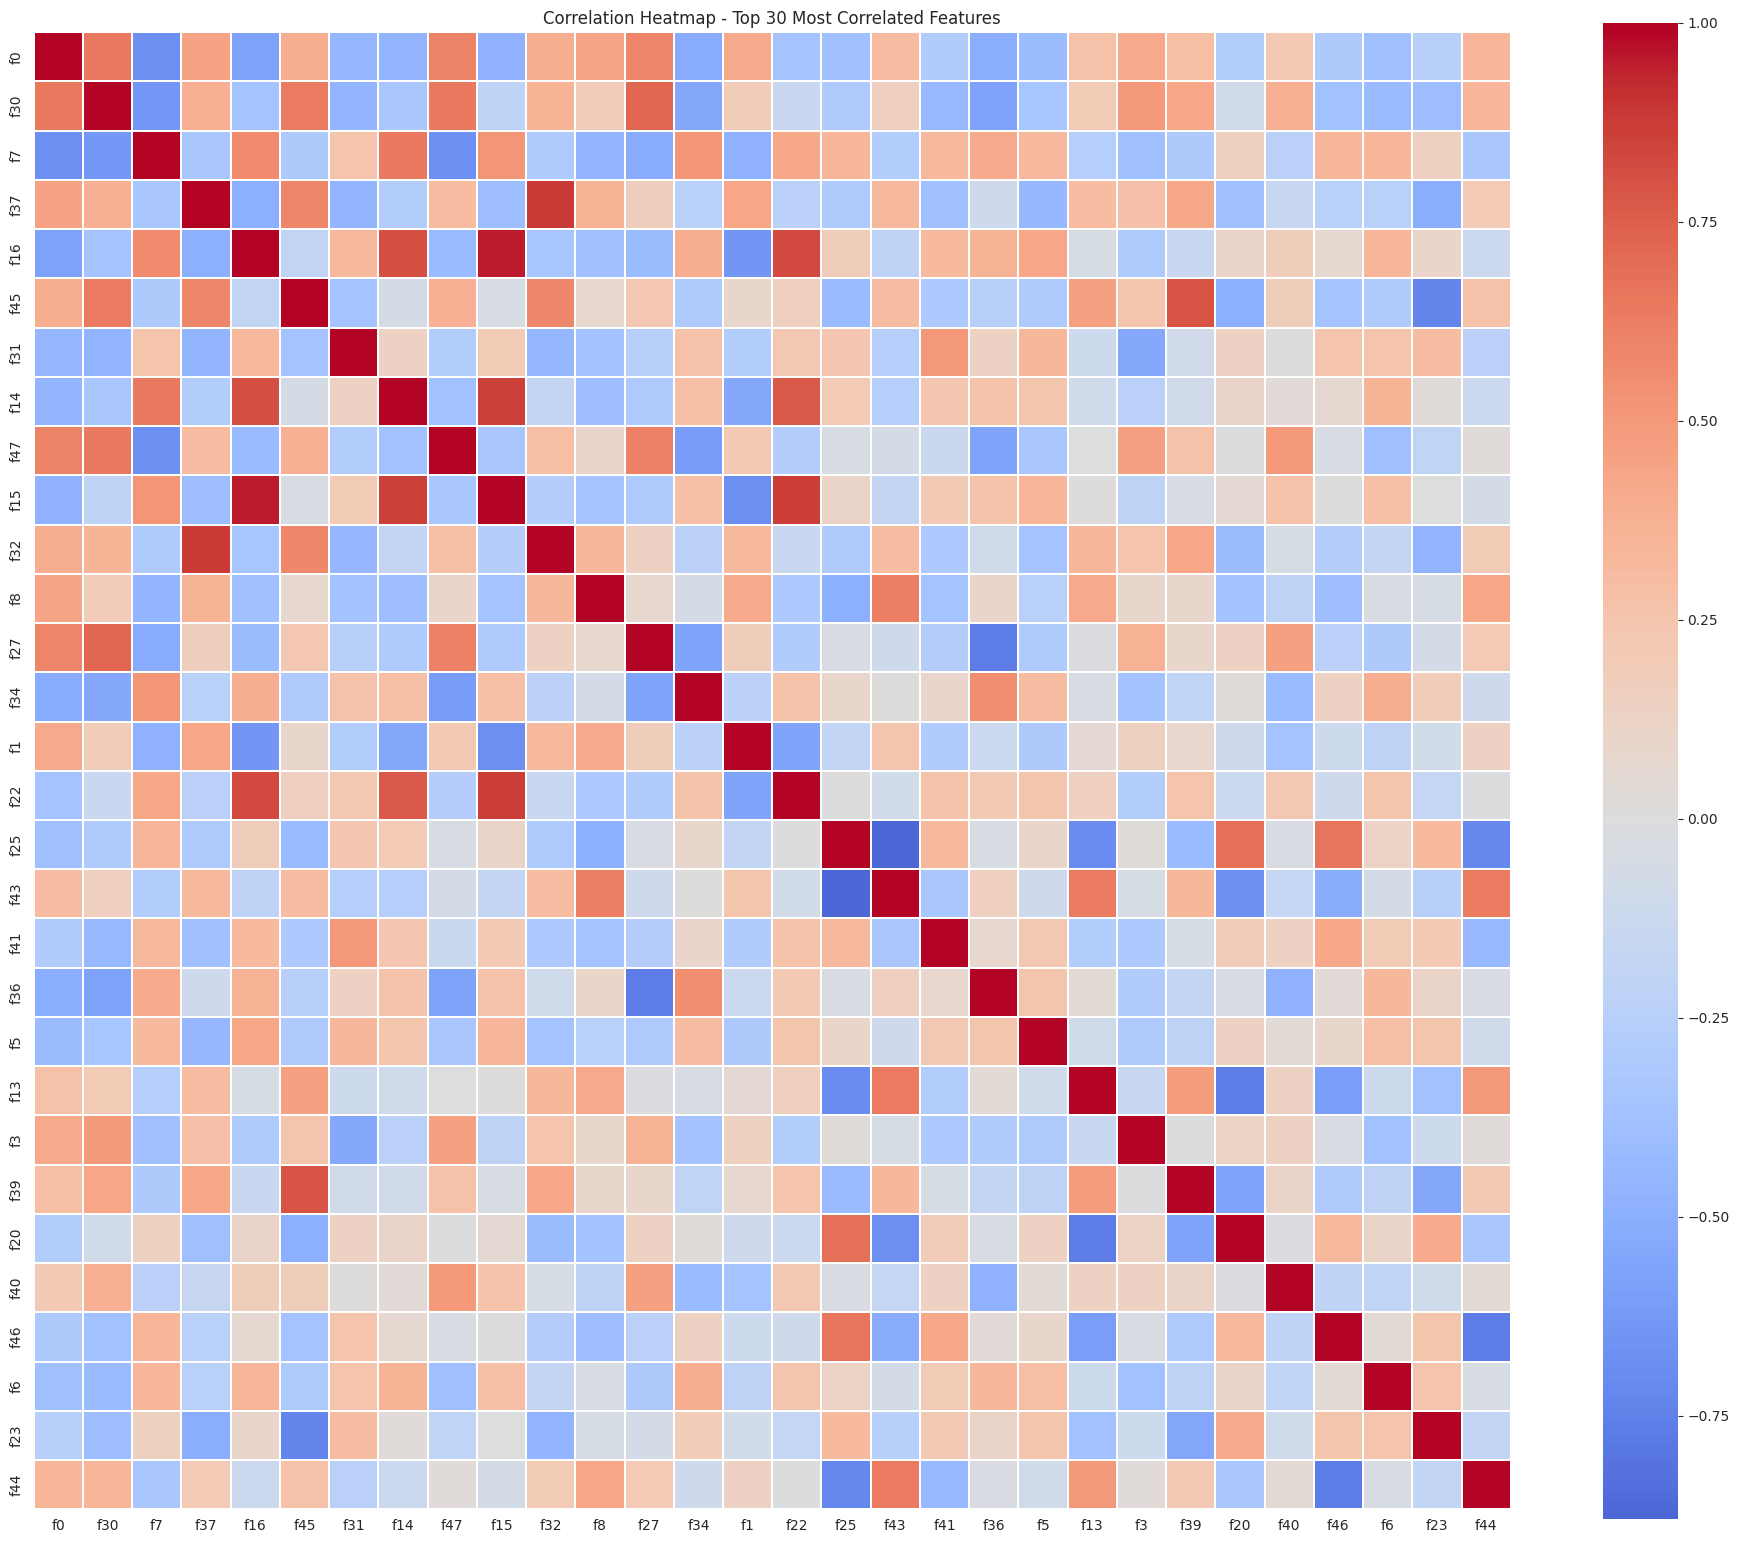

In [46]:
# Correlation heatmap

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
 
if TOP_K is not None and TOP_K < len(numeric_df.columns):
    avg_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
    plot_cols = avg_abs_corr.head(TOP_K).index
    heatmap_title = f"Correlation Heatmap - Top {TOP_K} Most Correlated Features"
else:
    plot_cols = numeric_df.columns
    heatmap_title = "Correlation Heatmap - All Numeric Features"
 
fig, ax = plt.subplots(figsize=(min(24, len(plot_cols) * 0.5 + 4), min(20, len(plot_cols) * 0.5 + 4)))
sns.heatmap(
    corr_matrix.loc[plot_cols, plot_cols],
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title(heatmap_title)
plt.tight_layout()
plt.show()

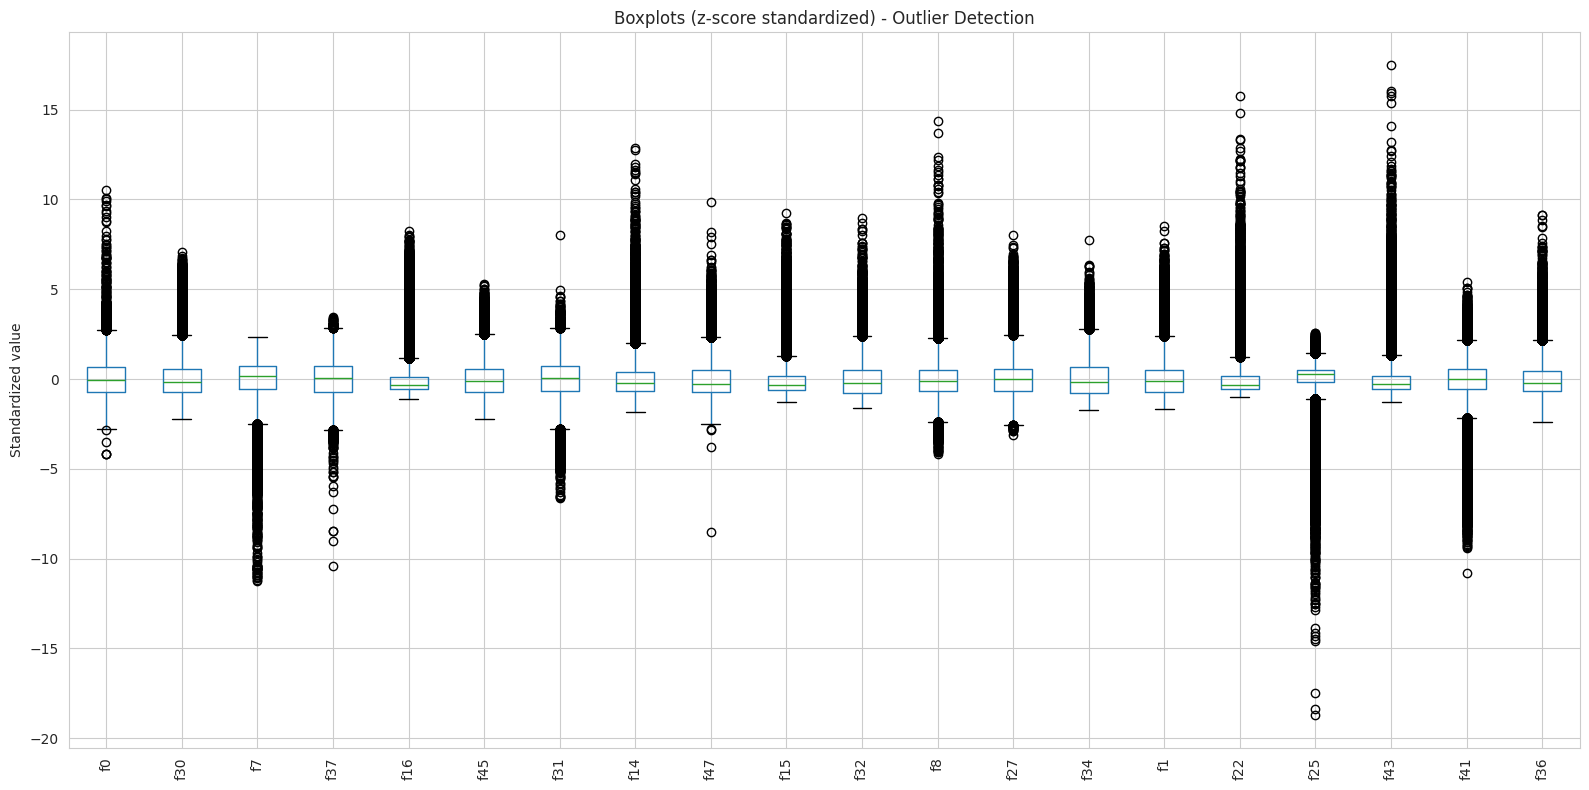

In [47]:
boxplot_cols = plot_cols[:20]  # cap at 20 for readability regardless of TOP_K
standardized = numeric_df[boxplot_cols].apply(zscore, nan_policy="omit")
 
fig, ax = plt.subplots(figsize=(16, 8))
standardized.boxplot(ax=ax, rot=90)
ax.set_title("Boxplots (z-score standardized) - Outlier Detection")
ax.set_ylabel("Standardized value")
plt.tight_layout()
plt.show()

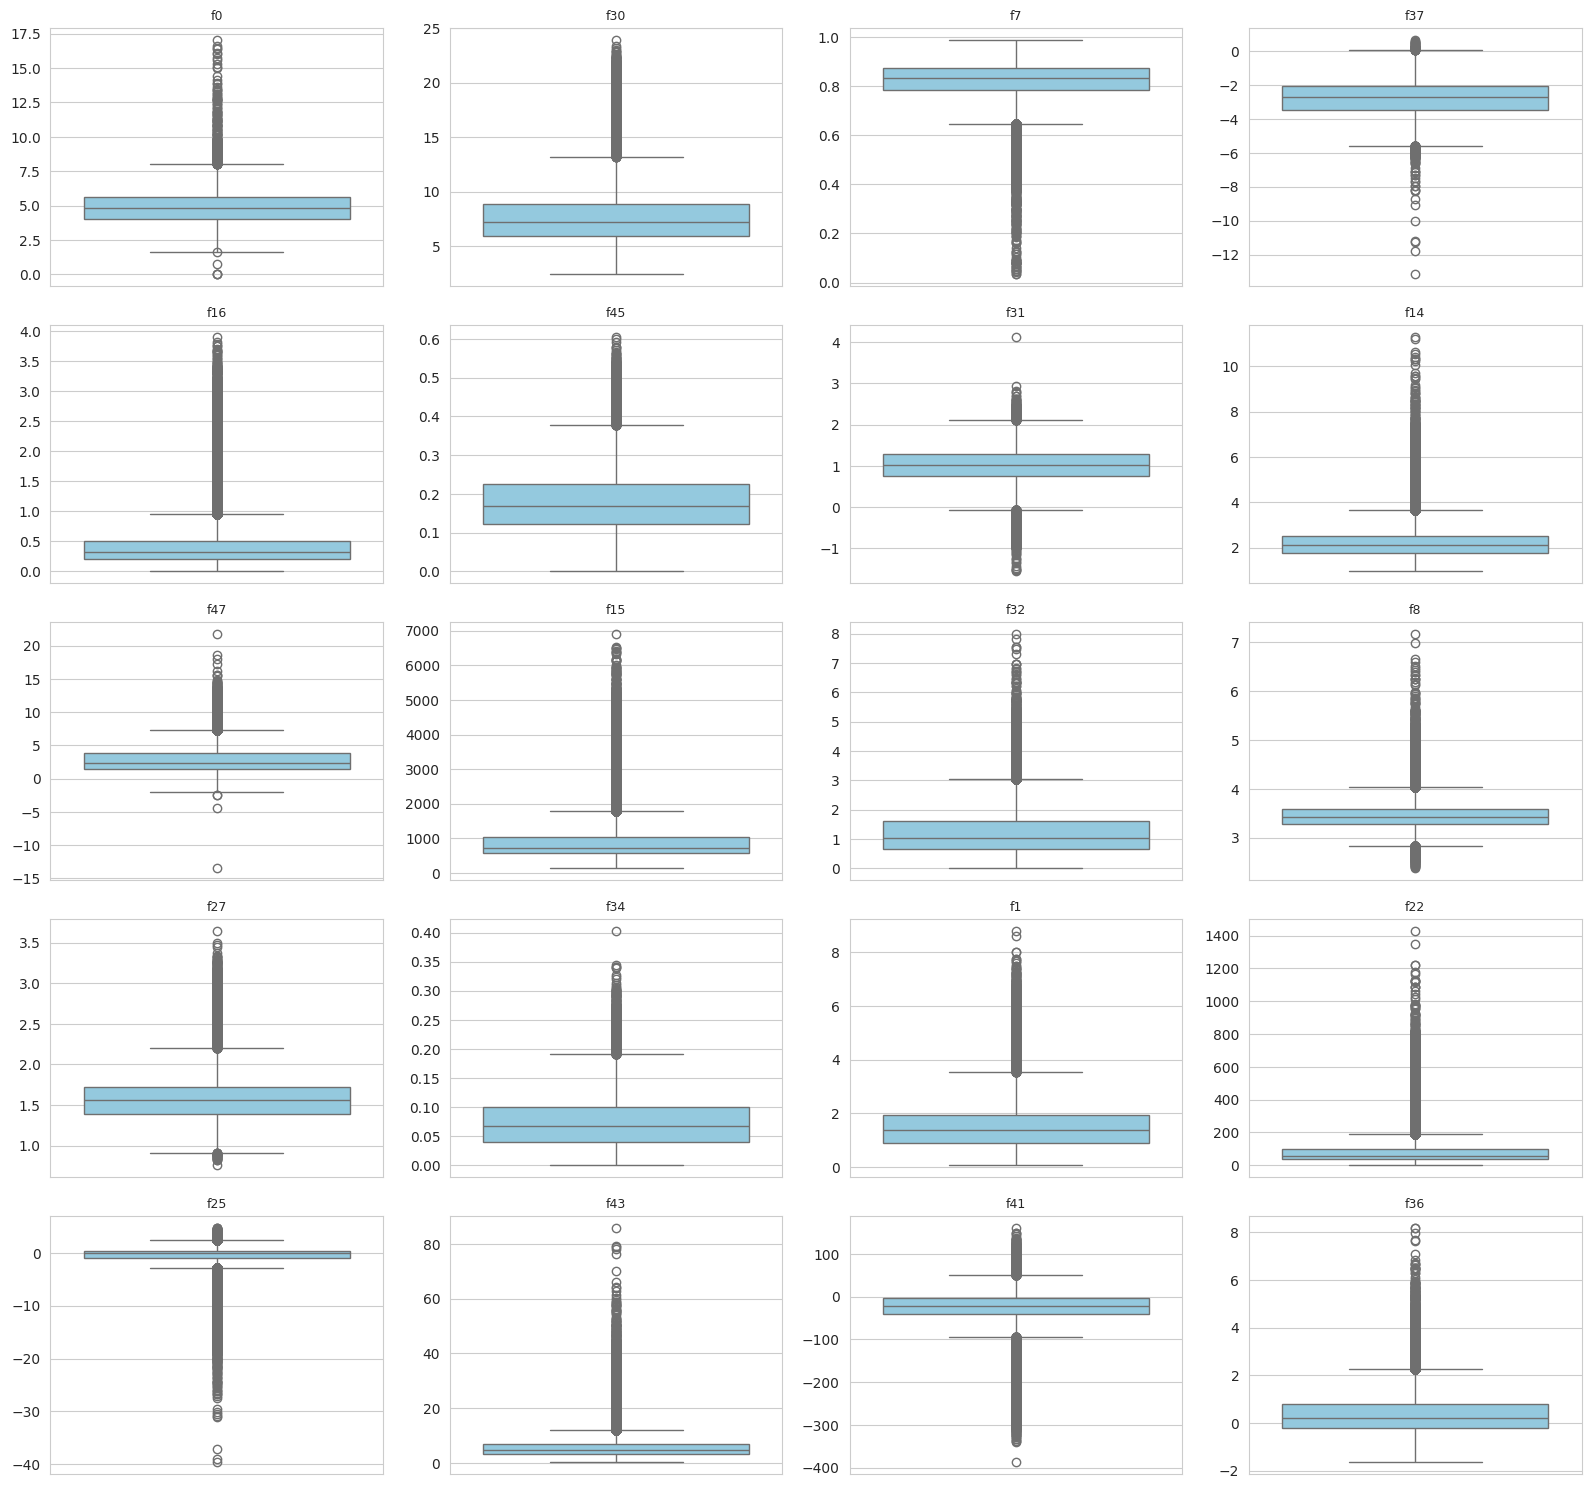

In [48]:
n_cols = 4
n_rows = int(np.ceil(len(boxplot_cols) / n_cols))
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
 
for i, col in enumerate(boxplot_cols):
    sns.boxplot(y=numeric_df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
 
for j in range(len(boxplot_cols), len(axes)):
    axes[j].axis("off")
 
plt.tight_layout()
plt.show()

In [49]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())
 
outlier_counts = (
    numeric_df[boxplot_cols]
    .apply(iqr_outlier_count)
    .sort_values(ascending=False)
    .to_frame("n_outliers")
)
outlier_counts["pct_outliers"] = (outlier_counts["n_outliers"] / len(numeric_df) * 100).round(2)
outlier_counts

,n_outliers,pct_outliers
f16,12864,9.89
f25,12792,9.84
f15,11620,8.93
f22,11104,8.54
f43,9948,7.65
f14,5662,4.35
f36,5127,3.94
f47,4469,3.44
f41,3748,2.88
f32,3607,2.77
